In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from collections import Counter

# Download latest version
DATASET_PATH = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")

print("Path to dataset files:", DATASET_PATH)

100%|██████████| 122M/122M [00:05<00:00, 22.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumithsingh/blood-cell-images-for-cancer-detection/versions/2


In [ ]:
# Detectando as classes do dataset
classes = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
print(f"Classes encontradas: {classes}")
print(f"Número de classes: {len(classes)}")

Classes encontradas: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']
Número de classes: 5


In [ ]:
# Contando quantas imagens há em cada classe
counts = {}
for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    counts[cls] = len([f for f in os.listdir(cls_dir) if os.path.isfile(os.path.join(cls_dir, f))])

print("Número de imagens por classe:")
for cls, cnt in counts.items():
  print(f" {cls:15s} -> {cnt} imagens")

Número de imagens por classe:
 basophil        -> 1000 imagens
 erythroblast    -> 1000 imagens
 monocyte        -> 1000 imagens
 myeloblast      -> 1000 imagens
 seg_neutrophil  -> 1000 imagens



Classe `basophil` - Exemplo `BA_545506.jpg`
Dimensões (largura x altura):  (360, 363)
Modo de cor:  RGB


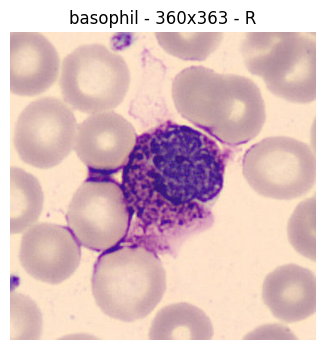


Classe `erythroblast` - Exemplo `ERB_272885.jpg`
Dimensões (largura x altura):  (360, 363)
Modo de cor:  RGB


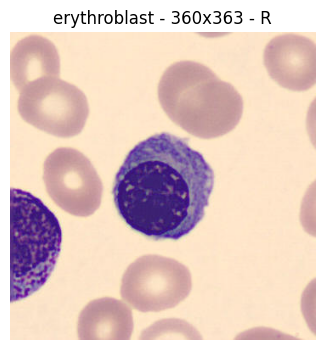


Classe `monocyte` - Exemplo `MO_721856.jpg`
Dimensões (largura x altura):  (360, 363)
Modo de cor:  RGB


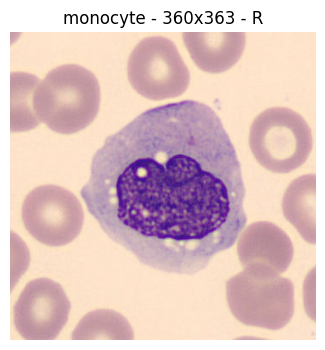


Classe `myeloblast` - Exemplo `MYO_1062.jpg`
Dimensões (largura x altura):  (400, 400)
Modo de cor:  RGB


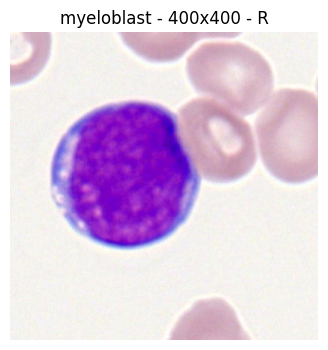


Classe `seg_neutrophil` - Exemplo `NGS_7620.jpg`
Dimensões (largura x altura):  (400, 400)
Modo de cor:  RGB


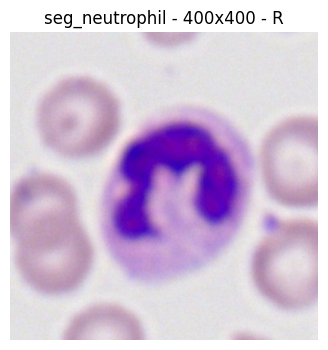

In [ ]:
# Inspeciando um exemplo de cada classe (tamanho e modo de cor)
for cls in classes:
  cls_dir = os.path.join(DATASET_PATH, cls)
  sample_file = next(iter(os.listdir(cls_dir))) # primeiro arquivo qualquer
  img_path = os.path.join(cls_dir, sample_file)

  with Image.open(img_path) as img:
    print(f"\nClasse `{cls}` - Exemplo `{sample_file}`")
    print("Dimensões (largura x altura): ", img.size)
    print("Modo de cor: ", img.mode)

    # Exibindo a imagem de exemplo
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"{cls} - {img.size[0]}x{img.size[1]} - {img.mode[0]}")
    plt.axis("off")
    plt.show()

In [ ]:
# Histograma de cores (para cada classe)

for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    sample_files = os.listdir(cls_dir)[:3]  # Pegando 3 exemplos por classe para criar o histograma de cada classe

    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Histogramas de Cores para a Classe: {cls}', fontsize=16)

    for i, sample_file in enumerate(sample_files):
        img_path = os.path.join(cls_dir, sample_file)
        with Image.open(img_path) as img:
            img_array = np.array(img)

            plt.subplot(2, 3, i + 1)
            plt.imshow(img)
            plt.title(f'Amostra {i+1}', fontsize=10)
            plt.axis('off')

            plt.subplot(2, 3, i + 4)
            colors = ('red', 'green', 'blue')
            for j, color in enumerate(colors):
                histogram, bin_edges = np.histogram(img_array[:, :, j], bins=256, range=(0, 256))
                plt.plot(bin_edges[0:-1], histogram, color=color)
            plt.title('Histograma de Cores', fontsize=10)
            plt.xlabel('Intensidade do Pixel', fontsize=8)
            plt.ylabel('Contagem', fontsize=8)
            plt.tick_params(axis='both', which='major', labelsize=6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"cores_histograma_{cls}.png")
    plt.close()

In [ ]:
# Média e desvio padrão por canal RGB das imagens (considerando uma amostra de 100 imagens)

means, stds = [], []

for cls in classes:
  cls_dir = os.path.join(DATASET_PATH, cls)
  for img_name in os.listdir(cls_dir)[:100]:
    img_path = os.path.join(cls_dir, img_name)
    img = np.array(Image.open(img_path).resize((128, 128))) / 255.0
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.mean(means, axis=0)
stds = np.mean(stds, axis=0)

print(f"Média por canal RGB: {means}")
print(f"Desvio padrão por canal RGB: {stds}")


Média por canal RGB: [0.84344742 0.73052218 0.76433314]
Desvio padrão por canal RGB: [0.16462189 0.21649788 0.0832862 ]


In [ ]:
# Verificando resoluções para todas as imagens

image_sizes = []
for cls in classes:
  cls_dir = os.path.join(DATASET_PATH, cls)
  for img_name in os.listdir(cls_dir):
    img_path = os.path.join(cls_dir, img_name)
    with Image.open(img_path) as img:
      image_sizes.append(img.size)

size_counts = Counter(image_sizes)
print("Distribuição das resoluções (largura x altura) das imagens:")
for size, count in size_counts.items():
  print(f"{size} -> {count} imagens")

Distribuição das resoluções (largura x altura) das imagens:
(360, 363) -> 2887 imagens
(366, 369) -> 80 imagens
(360, 360) -> 33 imagens
(400, 400) -> 2000 imagens


In [ ]:
# Verificando se há imagens corrompidas ou não RGB

problems = []
for cls in classes:
  cls_dir = os.path.join(DATASET_PATH, cls)
  for img_name in os.listdir(cls_dir):
    try:
      with Image.open(os.path.join(cls_dir, img_name)) as img:
        if img.mode != "RGB":
          problems.append((cls, img_name, img.mode))
    except Exception as e:
      problems.append((cls, img_name, str(e)))

print(f"{len(problems)} arquivos com problemas detectados.")

0 arquivos com problemas detectados.


In [ ]:
# Resumo tabular com pandas
df_summary = pd.DataFrame.from_dict(counts, orient="index", columns=["num_imagens"])
df_summary.index.name = "classe"

print("\nResumo em tabela:")
print(df_summary)


Resumo em tabela:
                num_imagens
classe                     
basophil               1000
erythroblast           1000
monocyte               1000
myeloblast             1000
seg_neutrophil         1000
